# Data Fetching


<b> Objective: </b>
Organize data from GEUS into tabular form

----------------------

<i><b>Author: </b> Salvador Palma <br>
<b>Institution: </b> Copenhagen University </i>


### Imports

In [1]:
import os
import re
import json
import pandas as pd
from dataclasses import dataclass
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import numpy as np
import matplotlib.pyplot as plt

from GreenlandUtils import PlotSamplesOnMap, Printable, DFStats, MostCommonElements, displaySplit, verifyStratification

SEED = 42

### Setup

In [2]:
#Results from this notebook will be stored in this subfolder Data/{DATA_TYPE}/{MERGE_TYPE}/
DATA_TYPE = "Stream Sediment"
MERGE_TYPE = "Mean Merge"

#{SOURCE_CSV}.csv and {SOURCE_CSV}.json are the source data
#CSV is the actual data, JSON is the information about the columns (physical, chemical, etc...)
SOURCE_CSV = "stream-sediment"

DATA_PATH = f"Data/{DATA_TYPE}/{MERGE_TYPE}/"
os.makedirs(DATA_PATH, exist_ok=True)


def ReadColumnSchema(baseName: str) -> dict:
    with open(f"Data/{baseName}.json", "r") as f:
        return json.load(f)


rockDF = pd.read_csv(f"Data/{SOURCE_CSV}.csv", sep=";")

schema = ReadColumnSchema(SOURCE_CSV)
sampleCol = schema["sampleCol"]
metaCols = schema["metaCols"]
physicalCols = schema["physicalCols"]
locationCols = schema["locationCols"]

C:\Users\salva\AppData\Local\Temp\ipykernel_38440\2353496222.py:18: DtypeWarning: Columns (0: Treatmentyears) have mixed types. Specify dtype option on import or set low_memory=False.
  rockDF = pd.read_csv(f"Data/{SOURCE_CSV}.csv", sep=";")


In [12]:
DFStats(rockDF, metaCols, sampleCol=sampleCol)

Analyzing Elements: 100%|██████████| 523/523 [00:00<00:00, 4483.55it/s]

============================== Quantities ==============================
Rows:                          20158
Samples:                       17463


============================== Structure ==============================
Columns:                       534
Column Names:                  ['Details', 'Sampleno', 'Sampling year', 'Grain size micron', 'Longitude', 'Latitude', 'Elevation', 'Coordinate method', 'Collector', 'Treatmentyears', 'Laboratorynames', 'ACTLABS FUS ICP SiO2 wt%', 'ACTLABS FUS ICP TiO2 wt%', 'ACTLABS FUS ICP Al2O3 wt%', 'ACTLABS FUS ICP Fe2O3t wt%', 'ACTLABS FUS ICP Fe2O3 wt%', 'ACTLABS FUS ICP MnO wt%', 'ACTLABS FUS ICP MgO wt%', 'ACTLABS FUS ICP CaO wt%', 'ACTLABS FUS ICP Na2O wt%', 'ACTLABS FUS ICP K2O wt%', 'ACTLABS FUS ICP P2O5 wt%', 'ACTLABS FUS ICP Sum wt%', 'ACTLABS FUS XRF SiO2 wt%', 'ACTLABS FUS XRF TiO2 wt%', 'ACTLABS FUS XRF Al2O3 wt%', 'ACTLABS FUS XRF Fe2O3 wt%', 'ACTLABS FUS XRF MnO wt%', 'ACTLABS FUS XRF MgO wt%', 'ACTLABS FUS XRF CaO wt%', 'ACTLABS FUS

### Merging Samples

In [14]:



def BaseElementName(col: str) -> str:
    elemPattern = re.compile(r"([A-Za-z0-9\.]+)\s+(wt%|ppm|ppb|%)$")
    match = elemPattern.search(col)
    return f"{match.group(1)} {match.group(2)}" if match else None

#Decision: Remove BDL completely
def MaskBelowDetection(df: pd.DataFrame, metaCols: list) -> pd.DataFrame:
    elementCols = [col for col in df.columns if col not in metaCols]

    masked = df.copy()
    masked[elementCols] = masked[elementCols].apply(pd.to_numeric, errors="coerce").mask(lambda x: x <= 0)

    return masked

#Merge same element columns but diferent labs, methods, etc... into single column
def MergeAnalyticalColumns(df: pd.DataFrame, metaCols: list) -> pd.DataFrame:

    elementCols = [col for col in df.columns if col not in metaCols]

    groups = {}
    for col in elementCols:
        base = BaseElementName(col)
        if base is not None:
            groups.setdefault(base, []).append(col)
            
    if all(len(cols) == 1 for cols in groups.values()):
        return df

    merged = {base: df[cols].median(axis=1, skipna=True) for base, cols in groups.items()}

    return pd.concat([df[metaCols], pd.DataFrame(merged, index=df.index)], axis=1)

#Merge rows belonging to the same sample into one
def MergeSamples(df: pd.DataFrame, metaCols: list, sampleCol: str) -> pd.DataFrame:

    elementCols = [col for col in df.columns if col not in metaCols]

    elements_merged = df.groupby(sampleCol).agg({col: "median" for col in elementCols}).reset_index()
    elements_merged[elementCols] = np.log10(elements_merged[elementCols])

    metaData_merged = df[metaCols].drop_duplicates(subset=[sampleCol])

    return pd.merge(metaData_merged, elements_merged, on=sampleCol, how="inner")


def saveDF(df: pd.DataFrame, path: str, baseName: str):
    df.to_csv(f"{path}{baseName}.csv", sep=";", index=False)

maskedDF = MaskBelowDetection(rockDF, metaCols)
collapsedDF = MergeAnalyticalColumns(maskedDF, metaCols)
mergedDF = MergeSamples(collapsedDF, metaCols, sampleCol)

printable = Printable()
printable.title("Merge")
printable.add("Rows in", f"{len(rockDF)}")
printable.add("Element columns in", f"{len([c for c in rockDF.columns if c not in metaCols])}")
printable.rest()
printable.add("After column merge", f"{len([c for c in collapsedDF.columns if c not in metaCols])} elements")
printable.add("After row merge", f"{len(mergedDF)} samples")
printable.flush()

DFStats(mergedDF, metaCols, sampleCol=sampleCol)

============== Merge ==============
Rows in:              20158
Element columns in:   523


After column merge:   93 elements
After row merge:      17463 samples


Analyzing Elements: 100%|██████████| 93/93 [00:00<00:00, 2935.35it/s]

============================== Quantities ==============================
Rows:                          17463
Samples:                       17463


============================== Structure ==============================
Columns:                       104
Column Names:                  ['Details', 'Sampleno', 'Sampling year', 'Grain size micron', 'Longitude', 'Latitude', 'Elevation', 'Coordinate method', 'Collector', 'Treatmentyears', 'Laboratorynames', 'SiO2 wt%', 'TiO2 wt%', 'Al2O3 wt%', 'Fe2O3t wt%', 'Fe2O3 wt%', 'MnO wt%', 'MgO wt%', 'CaO wt%', 'Na2O wt%', 'K2O wt%', 'P2O5 wt%', 'Sum wt%', 'L.o.i. wt%', 'FeO wt%', 'Ag ppm', 'Al %', 'As ppm', 'Ba ppm', 'Be ppm', 'Bi ppm', 'Ca %', 'Cd ppm', 'Co ppm', 'Cr ppm', 'Cu ppm', 'Fe %', 'Hf ppm', 'K %', 'Li ppm', 'Mg %', 'Mn ppm', 'Mo ppm', 'Na %', 'Nb ppm', 'Ni ppm', 'P %', 'Pb ppm', 'Rb ppm', 'S %', 'Sb ppm', 'Sn ppm', 'Sr ppm', 'Ta ppm', 'Th ppm', 'Ti %', 'U ppb', 'V ppm', 'W ppm', 'Zn ppm', 'Zr ppm', 'Sc ppm', 'Y ppm', 'La ppm', 'Ce ppm',

### Geophysical Features

Adding:
- **Magnetic Anomaly** - How different the magnetic field is from the reference field
- **Heat Flow** - How much heat espaces the surface
- **Depth to Mono** - Thickness of the crust above the mantle


In [15]:
from sklearn.neighbors import NearestNeighbors
from GreenlandUtils import lonlatToUTM24N

GEOPHYSICS_PATH = "Data/Geophysics/"
GEO_PREFIX = "geo_"


def ReadESRIHeader(path: str) -> dict:
    with open(path, "r") as f:
        entries = [line.split() for line in f if line.strip()]

    header = {}
    for key, value in entries:
        header[key.lower()] = int(value) if value.lstrip("-").isdigit() else value
    return header


def SampleESRIGrid(df: pd.DataFrame, path: str, baseName: str) -> np.ndarray:
    header = ReadESRIHeader(f"{path}{baseName}.hdr")
    ncols, nrows = header["ncols"], header["nrows"]
    cell, nodata = header["cellsize"], header["nodata_value"]

    grid = np.memmap(f"{path}{baseName}.flt", dtype="<f4", mode="r", shape=(nrows, ncols))

    x, y = lonlatToUTM24N(df["Longitude"].to_numpy(float), df["Latitude"].to_numpy(float))

    col = np.floor((x - header["xllcorner"]) / cell).astype(int)
    row = np.floor((header["yllcorner"] + nrows * cell - y) / cell).astype(int)

    inside = (col >= 0) & (col < ncols) & (row >= 0) & (row < nrows)

    values = np.full(len(df), np.nan)
    values[inside] = grid[row[inside], col[inside]]
    values[values == nodata] = np.nan

    return values


def SampleXYZGrid(df: pd.DataFrame, path: str, baseName: str, valueCol: int = 2) -> np.ndarray:
    rows = []
    with open(f"{path}{baseName}.xyz", "r") as f:
        for line in f:
            if line.startswith("%") or not line.strip():
                continue
            rows.append(line.split())

    grid = np.array([[float(v) for v in row[:valueCol + 1]] for row in rows])

    tree = NearestNeighbors(n_neighbors=1).fit(grid[:, :2])
    _, positions = tree.kneighbors(df[["Longitude", "Latitude"]].to_numpy(float))

    return grid[positions[:, 0], valueCol]


def AddGeophysics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df[f"{GEO_PREFIX}magnetic_anomaly nT"] = SampleESRIGrid(df, GEOPHYSICS_PATH, "GREENMAG_magnetic_anomaly")
    df[f"{GEO_PREFIX}heat_flow mW/m2"] = SampleXYZGrid(df, GEOPHYSICS_PATH, "GeothermalHeatFlow")
    df[f"{GEO_PREFIX}depth_to_moho km"] = SampleXYZGrid(df, GEOPHYSICS_PATH, "DepthToMoho")

    return df


mergedDF = AddGeophysics(mergedDF)

geoCols = [col for col in mergedDF.columns if col.startswith(GEO_PREFIX)]

printable = Printable()
printable.title("Geophysical Features")
for col in geoCols:
    values = mergedDF[col]
    printable.add(col, f"valid: {values.notna().sum():>5}/{len(mergedDF)} ({values.notna().mean():.1%})  range: {values.min():>8.1f} to {values.max():<8.1f}")
printable.flush()

============================== Geophysical Features ==============================
geo_magnetic_anomaly nT:   valid: 17463/17463 (100.0%)  range:   -645.3 to 1189.7  
geo_heat_flow mW/m2:       valid: 17463/17463 (100.0%)  range:     30.1 to 86.7    
geo_depth_to_moho km:      valid: 17463/17463 (100.0%)  range:     21.1 to 46.8    


<Axes: title={'left': 'Depth to Moho at sample locations (km)  (17,463 samples)'}, xlabel='Longitude (EPSG:32624)', ylabel='Latitude (EPSG:32624)'>

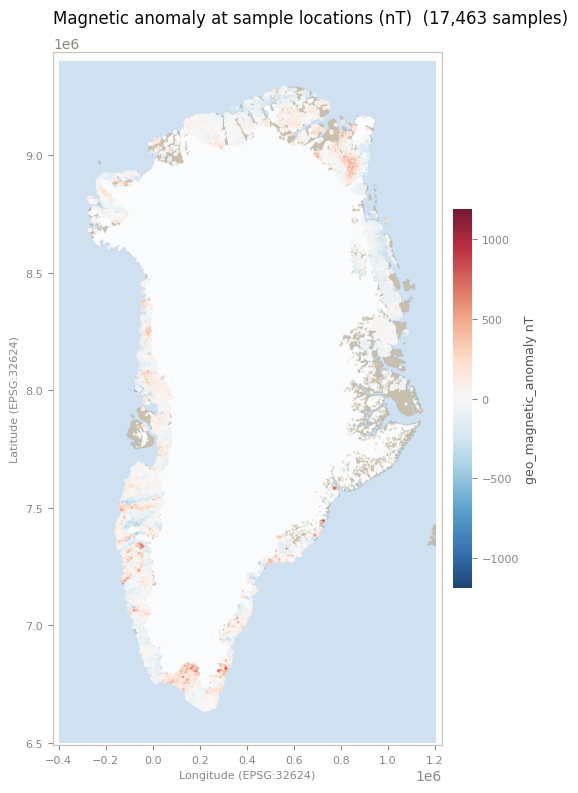

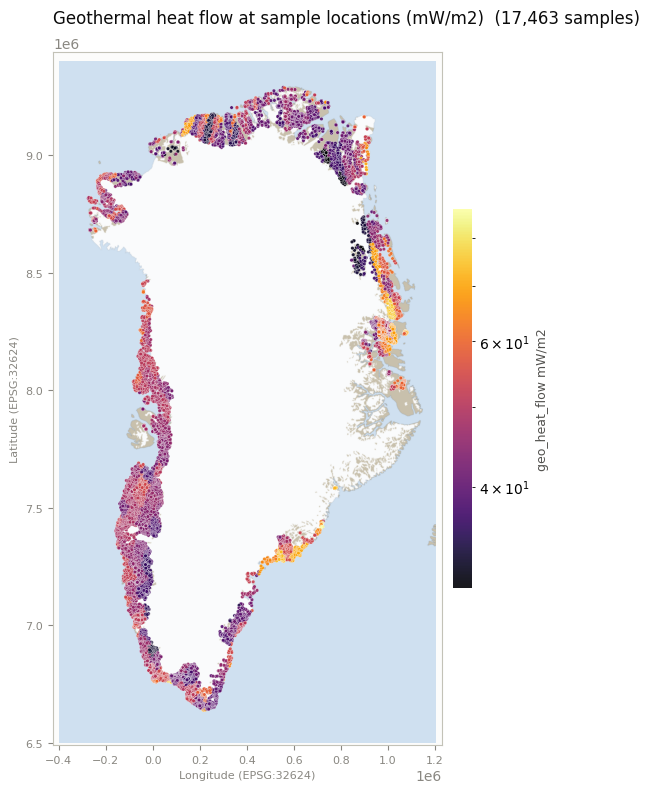

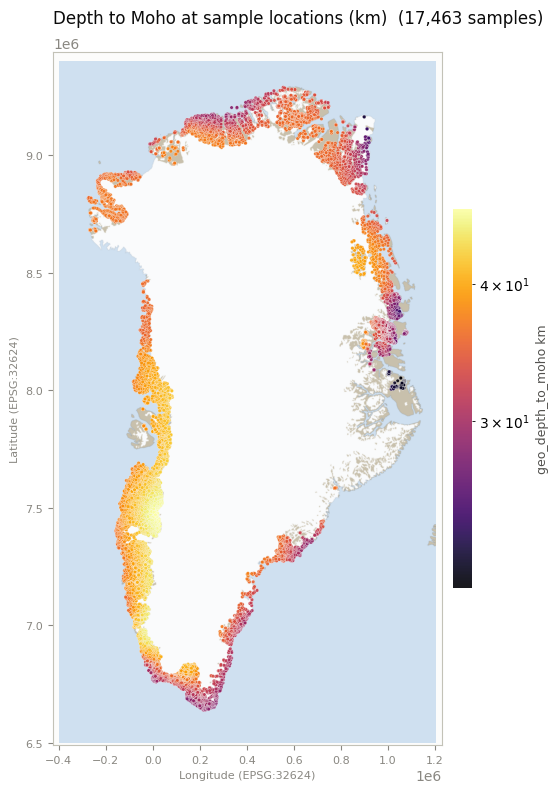

In [6]:
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}magnetic_anomaly nT", title="Magnetic anomaly at sample locations (nT)", cmap="RdBu_r", signed=True)
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}heat_flow mW/m2", title="Geothermal heat flow at sample locations (mW/m2)", cmap="inferno")
PlotSamplesOnMap(mergedDF, element=f"{GEO_PREFIX}depth_to_moho km", title="Depth to Moho at sample locations (km)", cmap="inferno")

##### Geophysics vs Geochemistry

In [17]:
from scipy.stats import pearsonr, spearmanr

MIN_PAIRS = 100


def CorrelateGeophysics(df: pd.DataFrame, geoCols: list[str], elementCols: list[str], minPairs: int = MIN_PAIRS) -> pd.DataFrame:

    x, y = lonlatToUTM24N(df["Longitude"].to_numpy(float), df["Latitude"].to_numpy(float))
    predictors = {col: df[col].to_numpy(float) for col in geoCols}
    predictors["(easting)"] = x
    predictors["(northing)"] = y

    rows = []
    for element in elementCols:
        target = df[element].to_numpy(float)

        for name, values in predictors.items():
            paired = np.isfinite(target) & np.isfinite(values)
            if paired.sum() < minPairs:
                continue

            rows.append({
                "element": element,
                "predictor": name,
                "n": int(paired.sum()),
                "pearson": pearsonr(values[paired], target[paired])[0],
                "spearman": spearmanr(values[paired], target[paired])[0],
            })

    return pd.DataFrame(rows)


elementCols = [col for col in mergedDF.columns if col not in metaCols + physicalCols]

correlations = CorrelateGeophysics(mergedDF, geoCols, elementCols)

printable = Printable()
printable.title("Element Correlations")
for name in geoCols:
    subset = correlations[correlations["predictor"] == name]
    subset = subset.reindex(subset["spearman"].abs().sort_values(ascending=False).index)

    printable.add(name, "")
    for _, row in subset.head(8).iterrows():
        printable.add(f"   {row['element']}", f"spearman {row['spearman']:>+6.3f}   pearson {row['pearson']:>+6.3f}   n={int(row['n'])}")
    printable.rest()

printable.title("Position Correlations")
for name in ["(easting)", "(northing)"]:
    subset = correlations[correlations["predictor"] == name]
    subset = subset.reindex(subset["spearman"].abs().sort_values(ascending=False).index)
    best = subset.iloc[0]
    printable.add(name, f"strongest: {best['element']} at spearman {best['spearman']:>+6.3f}   "
                        f"median |spearman| {subset['spearman'].abs().median():.3f}")
printable.flush()

============================== Element Correlations ==============================
geo_magnetic_anomaly nT:   
   S ppm:                  spearman +0.183   pearson +0.046   n=128
   Fe ppm:                 spearman -0.177   pearson -0.126   n=130
   Pr ppm:                 spearman +0.171   pearson +0.156   n=1402
   Mn %:                   spearman -0.170   pearson -0.179   n=2118
   Sn ppm:                 spearman +0.158   pearson +0.154   n=1739
   Mg %:                   spearman +0.147   pearson +0.121   n=4041
   Bi ppm:                 spearman +0.143   pearson +0.233   n=943
   Sc ppm:                 spearman -0.131   pearson -0.080   n=13282


geo_heat_flow mW/m2:       
   Ho ppm:                 spearman +0.532   pearson +0.391   n=1394
   Dy ppm:                 spearman +0.526   pearson +0.379   n=1401
   Er ppm:                 spearman +0.523   pearson +0.380   n=1400
   Tm ppm:                 spearman +0.505   pearson +0.372   n=1396
   Gd ppm:                 spearm

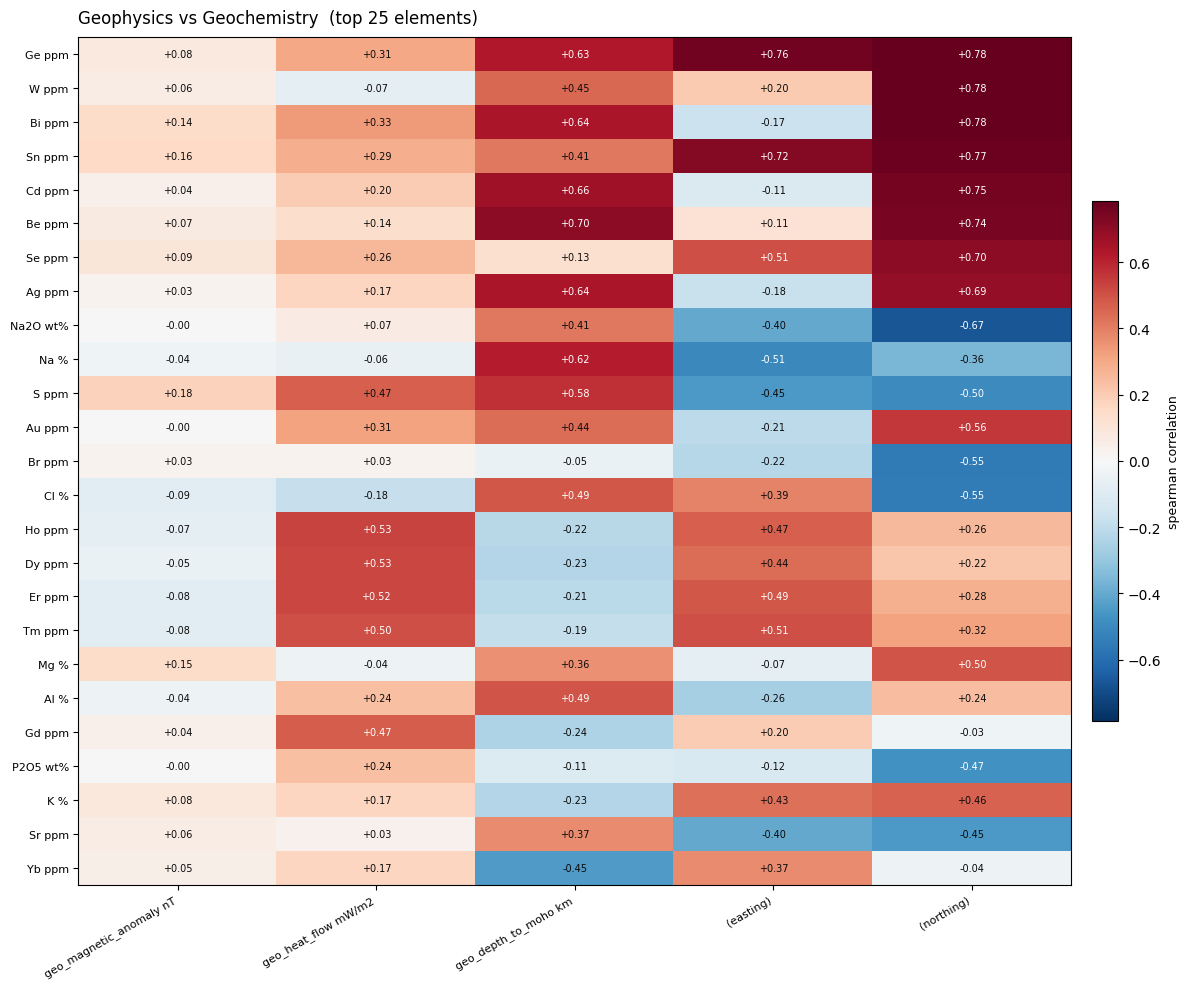

In [18]:
def DisplayCorrelationHeatmap(correlations: pd.DataFrame, predictors: list[str], metric: str = "spearman", topN: int = 25, title: str = "Geophysics vs Geochemistry"):

    grid = correlations.pivot(index="element", columns="predictor", values=metric)
    grid = grid.reindex(columns=[col for col in predictors if col in grid.columns])
    grid = grid.dropna(how="all")

    order = grid.abs().max(axis=1).sort_values(ascending=False).index[:topN]
    grid = grid.loc[order]

    fig, ax = plt.subplots(figsize=(1.6 * len(grid.columns) + 4, 0.32 * len(grid) + 2))

    limit = float(np.nanmax(np.abs(grid.to_numpy())))
    image = ax.imshow(grid.to_numpy(), cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")

    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(grid)))
    ax.set_yticklabels(grid.index, fontsize=8)

    for i in range(len(grid)):
        for j in range(len(grid.columns)):
            value = grid.to_numpy()[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=7,
                        color="white" if abs(value) > 0.6 * limit else PRIMARY)

    colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    colorbar.set_label(f"{metric} correlation", fontsize=9)

    ax.set_title(f"{title}  (top {len(grid)} elements)", fontsize=12, pad=10, loc="left")

    plt.tight_layout()
    plt.show()


from GreenlandUtils import PRIMARY

DisplayCorrelationHeatmap(correlations, geoCols + ["(easting)", "(northing)"], metric="spearman")

In [9]:
saveDF(mergedDF, DATA_PATH, "Data")

print(f"Saved {len(mergedDF)} samples, {len(mergedDF.columns)} columns ({len(geoCols)} geophysical)")

Saved 17463 samples, 107 columns (3 geophysical)


### Splitting & K-Fold

In [10]:
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
import json
from GreenlandUtils import Split


def splitDF(df: pd.DataFrame, ratios: list[float]=[0.8,0.1,0.1], method: str="random", **kwargs) -> Split:
    assert abs(sum(ratios) - 1.0) < 1e-9, "Ratios don't add up to 1.0"
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"
    
    train_ratio, val_ratio, test_ratio = ratios
    
    if method == "random":
        train_df, temp_df = train_test_split(df, train_size=train_ratio, test_size=test_ratio+val_ratio, random_state=SEED, shuffle=True)
        val_df, test_df = train_test_split(temp_df, test_size=test_ratio/(test_ratio+val_ratio), random_state=SEED, shuffle=True)
        return Split({ "train": train_df, "val": val_df, "test": test_df })


def splitKFold(df: pd.DataFrame, method: str="random", kfold: int=5, **kwargs) -> list[Split]:
    assert method in ["random", "kmeans"], "Method must be 'random' or 'kmeans'"

    if method == "random":
        splits = []
        for trainval_idx, test_idx in KFold(n_splits=kfold, shuffle=True, random_state=SEED).split(df):
            train_df, test_df = df.iloc[trainval_idx], df.iloc[test_idx]
            splits.append(Split({ "train": train_df, "val": pd.DataFrame(), "test": test_df }))
        return splits


def saveSplit(split: Split, baseName:str, path: str):
    json_result = {split_name: df.index.tolist() for split_name, df in split.data.items()}
    with open(f"{path}{baseName}.split", "w") as f:
        json.dump(json_result, f, indent=4)
  
def saveKFold(splits: list[Split], baseName:str, path: str):
    result = {i : {split_name: df.index.tolist() for split_name, df in split.data.items()} for i, split in enumerate(splits)}
    with open(f"{path}{baseName}.kfold", "w") as f:
        json.dump(result, f, indent=4)

#['Zn ppm', 'CaO wt%', 'Sr ppm', 'Ni ppm', 'Cr ppm', 'Al2O3 wt%', 'Cu ppm', 'Fe2O3 wt%', 'V ppm', 'Ba ppm']

split = splitDF(mergedDF, ratios=[0.8, 0.1, 0.1], method="random")
verifyStratification(split.data, "Cr ppm")

kfold_splits = splitKFold(mergedDF, method="random", kfold=5)

saveKFold(kfold_splits, "5-Fold", DATA_PATH)
saveSplit(split, "Holdout", DATA_PATH)

def SplitStats(split: Split):
    printable = Printable()
    printable.add("Train", f"{len(split.data['train'])} ({len(split.data['train'])/len(mergedDF)*100:.2f}%)")
    printable.add("Validation", f"{len(split.data['val'])} ({len(split.data['val'])/len(mergedDF)*100:.2f}%)")
    printable.add("Test", f"{len(split.data['test'])} ({len(split.data['test'])/len(mergedDF)*100:.2f}%)")
    printable.rest()
    printable.pretty()

for i, kfold_split in enumerate(kfold_splits):
    SplitStats(kfold_split)

========= Stratification Verification for Cr ppm =========
Total Samples:      17463
Train Ratio:        0.80 (0.67), Mean: 1.96
Validation Ratio:   0.10 (0.08), Mean: 1.95
Test Ratio:         0.10 (0.08), Mean: 1.97


Train:        13970 (80.00%)
Validation:   0 (0.00%)
Test:         3493 (20.00%)


Train:        13970 (80.00%)
Validation:   0 (0.00%)
Test:         3493 (20.00%)


Train:        13970 (80.00%)
Validation:   0 (0.00%)
Test:         3493 (20.00%)


Train:        13971 (80.00%)
Validation:   0 (0.00%)
Test:         3492 (20.00%)


Train:        13971 (80.00%)
Validation:   0 (0.00%)
Test:         3492 (20.00%)




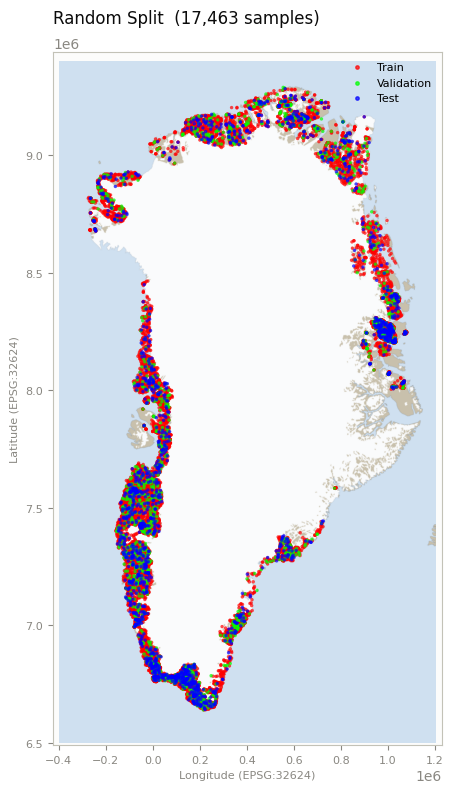

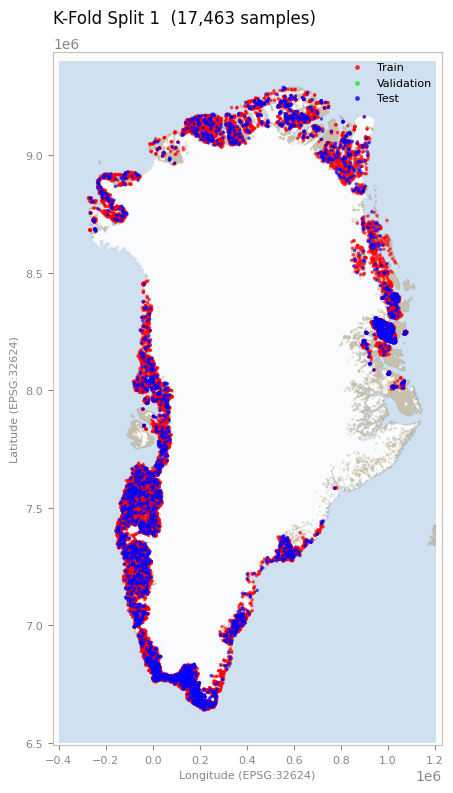

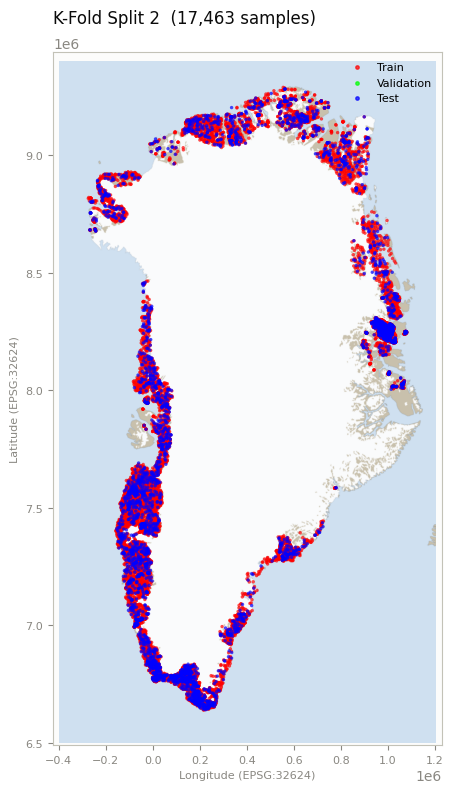

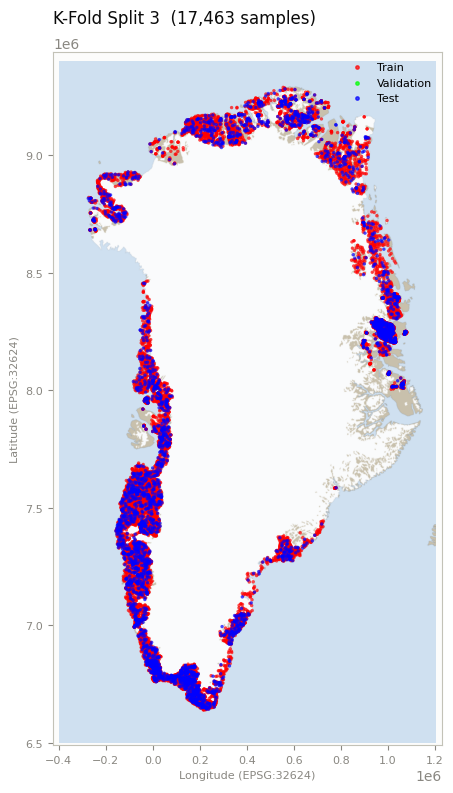

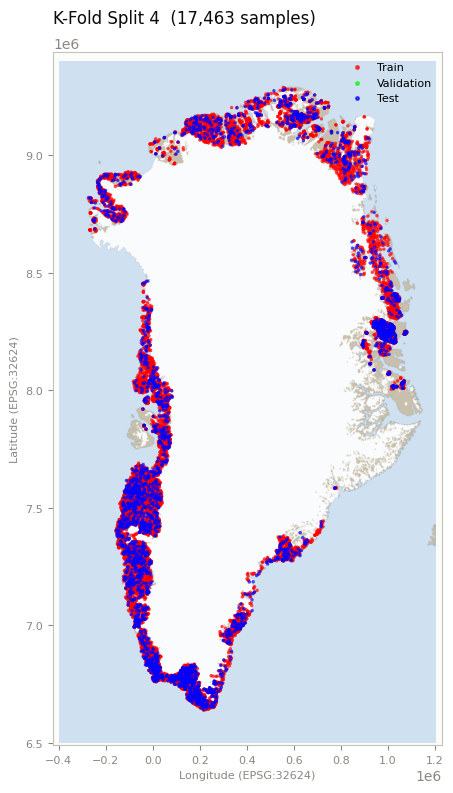

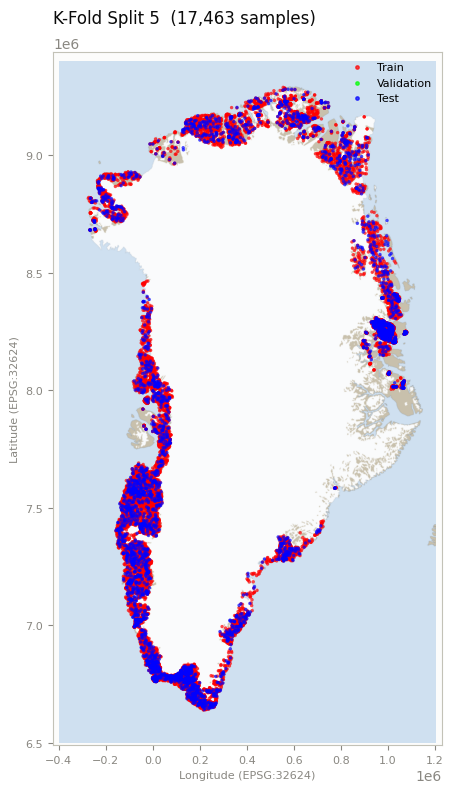

In [11]:
displaySplit(split.data, title="Random Split")

for i, kfold_split in enumerate(kfold_splits):
    displaySplit(kfold_split.data, title=f"K-Fold Split {i+1}")